In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "davidcariboo/player-scores" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\player-scores' already exists with files. Skipping download (replace=False).


In [3]:
files

['appearances.csv',
 'clubs.csv',
 'club_games.csv',
 'competitions.csv',
 'countries.csv',
 'games.csv',
 'game_events.csv',
 'game_lineups.csv',
 'national_teams.csv',
 'players.csv',
 'player_valuations.csv',
 'transfers.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,76,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(1862208, 13)

'Description'

,count,mean,std,min,25%,50%,75%,max
game_id,1862208.0,3286324.55,751845.38,2211607.0,2606535.0,3203656.0,3886492.0,4839901.0
player_id,1862208.0,235655.01,219774.73,10.0,61651.0,170767.0,342405.0,1510255.0
player_club_id,1862208.0,3315.38,9091.65,1.0,289.0,825.0,2439.0,132877.0
player_current_club_id,1862208.0,5345.56,13576.89,-1.0,367.0,987.0,3060.0,138189.0
yellow_cards,1862208.0,0.15,0.36,0.0,0.0,0.0,0.0,2.0
red_cards,1862208.0,0.00,0.06,0.0,0.0,0.0,0.0,1.0
goals,1862208.0,0.10,0.33,0.0,0.0,0.0,0.0,6.0
assists,1862208.0,0.08,0.28,0.0,0.0,0.0,0.0,6.0
minutes_played,1862208.0,68.64,30.15,1.0,45.0,90.0,90.0,148.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
appearance_id,object,0,1862208,"[4103827_571607, 3839583_116088, 2486765_45623]"
game_id,int64,0,72482,"[3063626, 4095275, 2497898]"
player_id,int64,0,28665,"[89297, 167798, 89450]"
player_club_id,int64,0,1180,"[6646, 306, 1049]"
player_current_club_id,int64,0,1100,"[6574, 903, 6912]"
date,object,0,4039,"[2016-05-12, 2015-10-18, 2024-08-25]"
player_name,object,2,28066,"[Arbnor Muja, Viktor Tsukanov, Jonathan Tah]"
competition_id,object,0,44,"[CDR, RU1, GR1]"
yellow_cards,int64,0,3,"[0, 0, 0]"
red_cards,int64,0,2,"[0, 0, 0]"


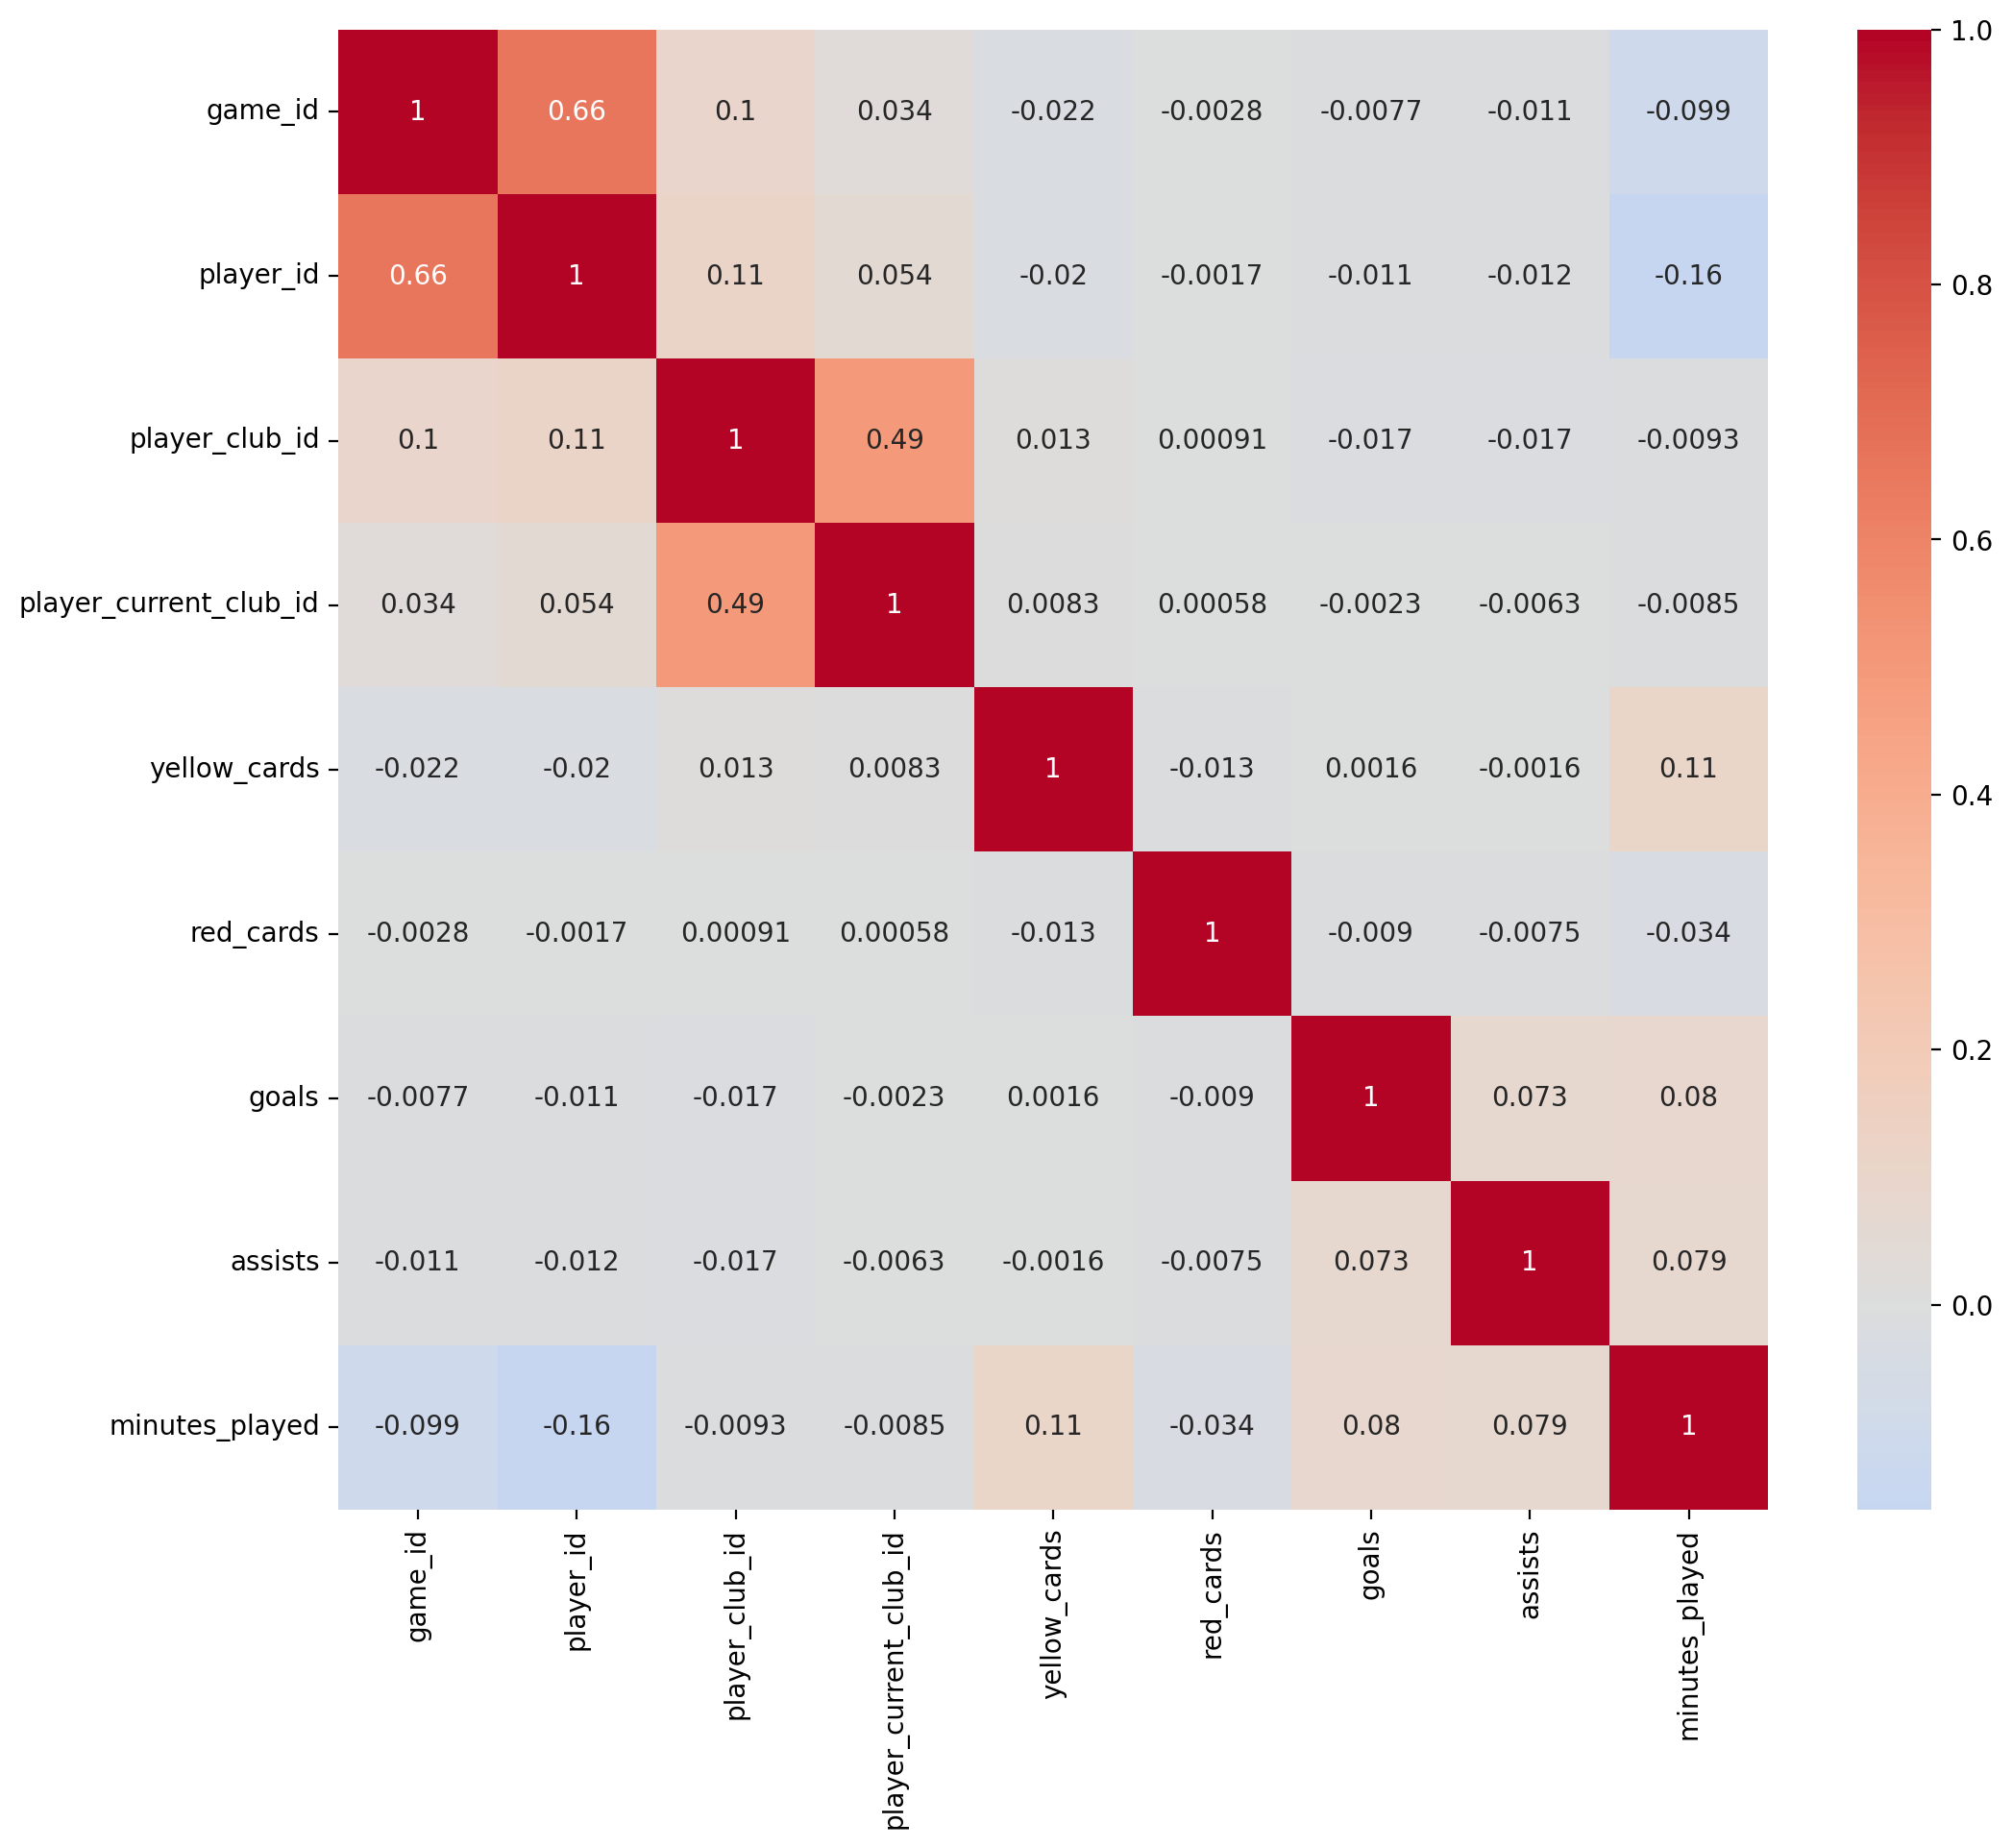

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

In [7]:
import pandas as pd
import os

data_path = r"C:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\data\raw\transfermarkt_data_2026-04-07"

if os.path.exists(data_path):
    csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
    print(f"Erfolg! Ordner gefunden.")
    print(f"Gefundene Tabellen: {len(csv_files)}\n")

    for file in csv_files:
        try:
            df_temp = pd.read_csv(os.path.join(data_path, file), nrows=0)
            print(f"### Tabelle: {file}")
            print(f"Spalten: {', '.join(df_temp.columns.tolist())}")
            print("-" * 30)
        except Exception as e:
            print(f"Fehler bei {file}: {e}")
else:
    print(f"FEHLER: Der Pfad wurde immer noch nicht gefunden.")
    print(f"Aktueller Arbeitsordner von Python: {os.getcwd()}")

Erfolg! Ordner gefunden.
Gefundene Tabellen: 12

### Tabelle: appearances.csv
Spalten: appearance_id, game_id, player_id, player_club_id, player_current_club_id, date, player_name, competition_id, yellow_cards, red_cards, goals, assists, minutes_played
------------------------------
### Tabelle: clubs.csv
Spalten: club_id, club_code, name, domestic_competition_id, total_market_value, squad_size, average_age, foreigners_number, foreigners_percentage, national_team_players, stadium_name, stadium_seats, net_transfer_record, coach_name, last_season, filename, url
------------------------------
### Tabelle: club_games.csv
Spalten: game_id, club_id, own_goals, own_position, own_manager_name, opponent_id, opponent_goals, opponent_position, opponent_manager_name, hosting, is_win
------------------------------
### Tabelle: competitions.csv
Spalten: competition_id, competition_code, name, sub_type, type, country_id, country_name, domestic_league_code, confederation, total_clubs, url
------------

In [8]:
import duckdb

data_path = r"C:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\data\raw\transfermarkt_data_2026-04-07"
players_file = data_path + r"\players.csv"
valuations_file = data_path + r"\player_valuations.csv"

query = f"""
SELECT 
    p.name, 
    p.current_club_name, 
    v.market_value_in_eur, 
    v.date
FROM read_csv_auto('{players_file}') AS p
JOIN read_csv_auto('{valuations_file}') AS v ON p.player_id = v.player_id
WHERE v.date > '2023-01-01'
ORDER BY v.market_value_in_eur DESC
LIMIT 10
"""

df_result = duckdb.query(query).to_df()

print("Die 10 wertvollsten Marktwerte seit 2023 (via SQL abgefragt):")
display(df_result)

Die 10 wertvollsten Marktwerte seit 2023 (via SQL abgefragt):


,name,current_club_name,market_value_in_eur,date
0,Vinicius Junior,Real Madrid Club de Fútbol,200000000,2024-12-27
1,Kylian Mbappé,Real Madrid Club de Fútbol,200000000,2025-12-12
2,Erling Haaland,Manchester City Football Club,200000000,2025-12-09
3,Erling Haaland,Manchester City Football Club,200000000,2024-10-01
4,Erling Haaland,Manchester City Football Club,200000000,2024-12-16
5,Vinicius Junior,Real Madrid Club de Fútbol,200000000,2024-10-11
6,Lamine Yamal,Futbol Club Barcelona,200000000,2025-12-12
7,Lamine Yamal,Futbol Club Barcelona,200000000,2025-06-09
8,Jude Bellingham,Real Madrid Club de Fútbol,180000000,2024-06-07
9,Erling Haaland,Manchester City Football Club,180000000,2023-06-20


In [9]:
query_top_10_unique = f"""
SELECT 
    p.name, 
    p.current_club_name, 
    MAX(v.market_value_in_eur) as max_market_value,
    MAX(v.date) as last_valuation_date
FROM read_csv_auto('{players_file}') AS p
JOIN read_csv_auto('{valuations_file}') AS v ON p.player_id = v.player_id
GROUP BY p.name, p.current_club_name
ORDER BY max_market_value DESC
LIMIT 10
"""

df_unique_top_10 = duckdb.query(query_top_10_unique).to_df()

print("Die 10 wertvollsten Einzelspieler (Stand April 2026):")
display(df_unique_top_10)

Die 10 wertvollsten Einzelspieler (Stand April 2026):


,name,current_club_name,max_market_value,last_valuation_date
0,Lamine Yamal,Futbol Club Barcelona,200000000,2025-12-12
1,Kylian Mbappé,Real Madrid Club de Fútbol,200000000,2025-12-12
2,Erling Haaland,Manchester City Football Club,200000000,2025-12-09
3,Vinicius Junior,Real Madrid Club de Fútbol,200000000,2025-12-12
4,Lionel Messi,Club Internacional de Fútbol Miami,180000000,2025-12-11
5,Jude Bellingham,Real Madrid Club de Fútbol,180000000,2026-03-16
6,Neymar,Santos Futebol Clube,180000000,2025-12-10
7,Raheem Sterling,Feyenoord Rotterdam,160000000,2025-12-09
8,Antoine Griezmann,Club Atlético de Madrid S.A.D.,150000000,2026-03-16
9,Phil Foden,Manchester City Football Club,150000000,2025-12-09


In [10]:
query_top_10_simple = f"""
SELECT 
    name, 
    current_club_name, 
    market_value_in_eur,
    position,
    last_season
FROM read_csv_auto('{players_file}')
WHERE last_season = 2025  -- Nur aktive Spieler
AND market_value_in_eur IS NOT NULL
ORDER BY market_value_in_eur DESC
LIMIT 10
"""

df_top_10 = duckdb.query(query_top_10_simple).to_df()
display(df_top_10)

,name,current_club_name,market_value_in_eur,position,last_season
0,Kylian Mbappé,Real Madrid Club de Fútbol,200000000,Attack,2025
1,Lamine Yamal,Futbol Club Barcelona,200000000,Attack,2025
2,Erling Haaland,Manchester City Football Club,200000000,Attack,2025
3,Pedri,Futbol Club Barcelona,150000000,Midfield,2025
4,Vinicius Junior,Real Madrid Club de Fútbol,150000000,Attack,2025
5,Michael Olise,FC Bayern München,140000000,Attack,2025
6,Jude Bellingham,Real Madrid Club de Fútbol,140000000,Midfield,2025
7,Jamal Musiala,FC Bayern München,120000000,Midfield,2025
8,Bukayo Saka,Arsenal Football Club,120000000,Attack,2025
9,Declan Rice,Arsenal Football Club,120000000,Midfield,2025


In [11]:
data_path = r"C:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\data\raw\transfermarkt_data_2026-04-07"

csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

print("--- DATEN-INVENTUR: FEHLENDE WERTE ---")

for file in csv_files:
    df = pd.read_csv(os.path.join(data_path, file))
    
    missing = df.isnull().sum()
    percent = (df.isnull().sum() / len(df)) * 100
    
    missing_table = pd.DataFrame({'Absolut': missing, 'Prozent': percent})
    missing_only = missing_table[missing_table['Absolut'] > 0]
    
    print(f"\n### Tabelle: {file}")
    if not missing_only.empty:
        print(missing_only.sort_values(by='Prozent', ascending=False))
    else:
        print("Perfekt! Keine fehlenden Werte.")
    print("-" * 40)

--- DATEN-INVENTUR: FEHLENDE WERTE ---

### Tabelle: appearances.csv
             Absolut   Prozent
player_name        2  0.000107
----------------------------------------

### Tabelle: clubs.csv
                       Absolut     Prozent
total_market_value         796  100.000000
coach_name                 706   88.693467
foreigners_percentage       57    7.160804
average_age                 38    4.773869
----------------------------------------

### Tabelle: club_games.csv
                       Absolut    Prozent
own_position             50444  28.996471
opponent_position        50444  28.996471
own_manager_name          1688   0.970305
opponent_manager_name     1688   0.970305
----------------------------------------

### Tabelle: competitions.csv
                      Absolut    Prozent
total_clubs                16  23.880597
country_name               13  19.402985
domestic_league_code       13  19.402985
----------------------------------------

### Tabelle: countries.csv
Perf

C:\Users\Trainee\AppData\Local\Temp\ipykernel_4668\1669892820.py:8: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(data_path, file))



### Tabelle: game_lineups.csv
          Absolut   Prozent
position        3  0.000098
----------------------------------------

### Tabelle: national_teams.csv
                       Absolut     Prozent
coach_name                 118  100.000000
foreigners_percentage        5    4.237288
total_market_value           3    2.542373
confederation                1    0.847458
----------------------------------------

### Tabelle: players.csv
                                      Absolut    Prozent
current_national_team_id                44611  93.520188
international_goals                     29979  62.846422
international_caps                      29979  62.846422
agent_name                              22180  46.497002
contract_expiration_date                16488  34.564588
market_value_in_eur                      8476  17.768647
highest_market_value_in_eur              8476  17.768647
foot                                     5256  11.018406
country_of_birth                         516

In [12]:
# Test: Marktwerte pro Verein aggregieren (Beispiel Bundesliga)
query_club_check = f"""
SELECT 
    current_club_name, 
    COUNT(player_id) as squad_size,
    SUM(market_value_in_eur) / 1000000 as calc_total_market_value_mio
FROM read_csv_auto('{players_file}')
WHERE current_club_domestic_competition_id = 'L1' 
AND last_season = 2023
GROUP BY current_club_name
ORDER BY calc_total_market_value_mio DESC
"""
df_club_test = duckdb.query(query_club_check).to_df()
display(df_club_test)

,current_club_name,squad_size,calc_total_market_value_mio
0,SV Darmstadt 98,21,21.200
1,1. Fußball-Club Köln,7,10.100
2,VfL Bochum,10,5.750
3,Turn- und Sportgemeinschaft 1899 Hoffenheim Fu...,5,5.500
4,Sportverein Werder Bremen von 1899,7,5.300
5,1. Fußball- und Sportverein Mainz 05,7,5.025
6,1. Fußballclub Heidenheim 1846,6,4.800
7,Eintracht Frankfurt Fußball AG,10,3.950
8,Borussia Verein für Leibesübungen 1900 Mönchen...,6,3.775
9,Sport-Club Freiburg,6,3.350


In [13]:
# ohne Saison-Filter
query_recheck_bayern = f"""
SELECT 
    name, 
    market_value_in_eur, 
    last_season
FROM read_csv_auto('{players_file}')
WHERE current_club_name = 'FC Bayern München'
ORDER BY market_value_in_eur DESC
"""
df_bayern = duckdb.query(query_recheck_bayern).to_df()
display(df_bayern)

,name,market_value_in_eur,last_season
0,Michael Olise,140000000,2025
1,Jamal Musiala,120000000,2025
2,Aleksandar Pavlovic,75000000,2025
3,Dayot Upamecano,70000000,2025
4,Luis Díaz,70000000,2025
...,...,...,...
58,Tom Starke,100000,2017
59,Fabian Benko,100000,2017
60,Lucas Scholl,75000,2014
61,Maximilian Riedmüller,25000,2012


In [14]:
# Wir suchen alle Spieler, die 2023 ein Spiel für Bayern (ID 27) bestritten haben
query_real_squad = f"""
SELECT 
    player_name, 
    COUNT(appearance_id) as games_played
FROM read_csv_auto('{data_path + r"/appearances.csv"}')
WHERE player_club_id = 27 
AND date BETWEEN '2023-08-01' AND '2026-03-31'
GROUP BY player_name
ORDER BY games_played DESC
"""
df_real_bayern = duckdb.query(query_real_squad).to_df()
display(df_real_bayern)

,player_name,games_played
0,Harry Kane,136
1,Joshua Kimmich,135
2,Konrad Laimer,123
3,Leon Goretzka,122
4,Min-jae Kim,108
5,Dayot Upamecano,105
6,Manuel Neuer,102
7,Serge Gnabry,101
8,Michael Olise,94
9,Jamal Musiala,93


In [15]:
query_no_value = f"""
SELECT name, current_club_name, last_season, position
FROM read_csv_auto('{players_file}')
WHERE market_value_in_eur IS NULL
AND last_season >= 2023
LIMIT 10
"""
display(duckdb.query(query_no_value).to_df())

,name,current_club_name,last_season,position
0,Paolo Guerrero,None,2025,Attack
1,Jamie Young,Melbourne City Football Club,2024,Goalkeeper
2,Josef Jindrisek,"Bohemians Praha 1905, a.s.",2024,Midfield
3,Ousmane Pato,Al-Okhdood Club,2024,Attack
4,Kyriakos Stamatopoulos,Allmänna Idrottsklubben,2024,Goalkeeper
5,Marek Matejovsky,"FK Mladá Boleslav, a.s.",2024,Midfield
6,Yuki Nakashima,Zelvia,2024,Attack
7,Jesús Corona,Club Tijuana Xoloitzcuintles de Caliente,2024,Goalkeeper
8,Andreas Lukse,Fußballclub Blau-Weiß Linz,2024,Goalkeeper
9,Enrique Bologna,Club Social y Deportivo Defensa y Justicia,2024,Goalkeeper


In [16]:
# Verknüpfung der Spielerliste (FC Bayern) aus den Einsätzen mit den Marktwerten
query_correct_total_value = f"""
WITH current_squad AS (
    -- Schritt 1: Wer hat diese Saison wirklich für Bayern gespielt?
    SELECT DISTINCT player_id, player_name
    FROM read_csv_auto('{data_path + r"/appearances.csv"}')
    WHERE player_club_id = 27 
    AND date > '2025-07-01'
)
-- Schritt 2: Marktwerte für diese Spieler addieren
SELECT 
    COUNT(s.player_id) as squad_size,
    SUM(p.market_value_in_eur) / 1000000 as total_market_value_mio,
    AVG(p.market_value_in_eur) / 1000000 as avg_player_value_mio
FROM current_squad s
JOIN read_csv_auto('{players_file}') p ON s.player_id = p.player_id
"""

df_bayern_real = duckdb.query(query_correct_total_value).to_df()
display(df_bayern_real)

,squad_size,total_market_value_mio,avg_player_value_mio
0,27,1013.5,37.537037


In [17]:
# Stichprobe: Marktwert Hamburger SV am 01.09.2025
hsv_id = 41

query_hsv_check = f"""
WITH hsv_squad AS (
    -- alle Spieler, die zwischen Saisonstart und dem 01.09.25 für den HSV gelistet waren
    SELECT DISTINCT player_id, player_name
    FROM read_csv_auto('{data_path + r"/appearances.csv"}')
    WHERE player_club_id = {hsv_id} 
    AND date BETWEEN '2025-07-01' AND '2025-12-01'
)
SELECT 
    '2025-09-01' as reference_date,
    COUNT(s.player_id) as squad_size,
    SUM(p.market_value_in_eur) / 1000000 as total_market_value_mio,
    ROUND(AVG(p.market_value_in_eur) / 1000000, 2) as avg_player_value_mio
FROM hsv_squad s
JOIN read_csv_auto('{players_file}') p ON s.player_id = p.player_id
"""

df_hsv_result = duckdb.query(query_hsv_check).to_df()
display(df_hsv_result)

,reference_date,squad_size,total_market_value_mio,avg_player_value_mio
0,2025-09-01,22,149.7,7.13


In [18]:
import duckdb
import pandas as pd


data_path = r"C:\Users\Trainee\Desktop\DPP_Projekte\DPP-2026_Julian\data\raw\transfermarkt_data_2026-04-07"
players_file = data_path + r"\players.csv"
competitions_file = data_path + r"\competitions.csv"
appearances_file = data_path + r"\appearances.csv"

query_league_coverage = f"""
SELECT 
    c.name AS league_name,
    c.country_name,
    COUNT(DISTINCT p.player_id) AS player_count,
    COUNT(DISTINCT a.appearance_id) AS total_appearances,
    ROUND(COUNT(p.market_value_in_eur) * 100.0 / COUNT(p.player_id), 1) AS market_value_coverage_percent,
    ROUND(AVG(p.market_value_in_eur) / 1000000, 2) AS avg_value_mio
FROM read_csv_auto('{competitions_file}') AS c
JOIN read_csv_auto('{players_file}') AS p ON c.competition_id = p.current_club_domestic_competition_id
LEFT JOIN read_csv_auto('{appearances_file}') AS a ON p.player_id = a.player_id
WHERE p.last_season >= 2023
GROUP BY c.name, c.country_name
HAVING total_appearances > 1000
ORDER BY total_appearances DESC
"""

df_coverage = duckdb.query(query_league_coverage).to_df()
print("Analyse der Datenverfügbarkeit pro Liga:")
display(df_coverage)

Analyse der Datenverfügbarkeit pro Liga:


,league_name,country_name,player_count,total_appearances,market_value_coverage_percent,avg_value_mio
0,premier-league,England,1026,108331,99.8,22.34
1,serie-a,Italy,997,105048,99.9,9.45
2,laliga,Spain,974,104595,99.8,10.92
3,super-lig,Türkiye,1178,92290,99.6,2.87
4,bundesliga,Germany,806,74989,99.9,10.38
5,ligue-1,France,834,70190,99.7,9.50
6,super-league-1,Greece,797,64246,99.8,1.29
7,eredivisie,Netherlands,867,63173,99.7,2.65
8,liga-portugal,Portugal,946,60386,99.8,4.05
9,premier-liga,Russia,824,58029,99.5,2.46


In [19]:
# Check: Wie viele Transfers haben eine bekannte Ablösesumme?
query_fee_check = f"""
SELECT 
    COUNT(*) as total_transfers,
    COUNT(transfer_fee) as transfers_with_fee,
    ROUND(COUNT(transfer_fee) * 100.0 / COUNT(*), 1) as fee_coverage_percent,
    SUM(transfer_fee) / 1000000 as total_spent_mio
FROM read_csv_auto('{data_path + r"/transfers.csv"}')
WHERE transfer_date > '2023-07-01' -- Fokus auf die letzten Jahre
"""
df_fees = duckdb.query(query_fee_check).to_df()
display(df_fees)

,total_transfers,transfers_with_fee,fee_coverage_percent,total_spent_mio
0,41698,31734,76.1,30653.4458
